### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


✅ Dataset loaded! Shape: (86, 9)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB
None

=== Summary Statistics (Before Cleaning) ===
           A1      A2      A3      A4      A5      A6      A7  Final_Exam
count   57.00   61.00   62.00   77.00   61.00   67.00   76.00       86.00
mean    83.67   81.10   68.17   82.33   89.65   74.44   78.13       55.51
std     34.29   28.56   42.34   39.10   25.51   31.18   26.41      

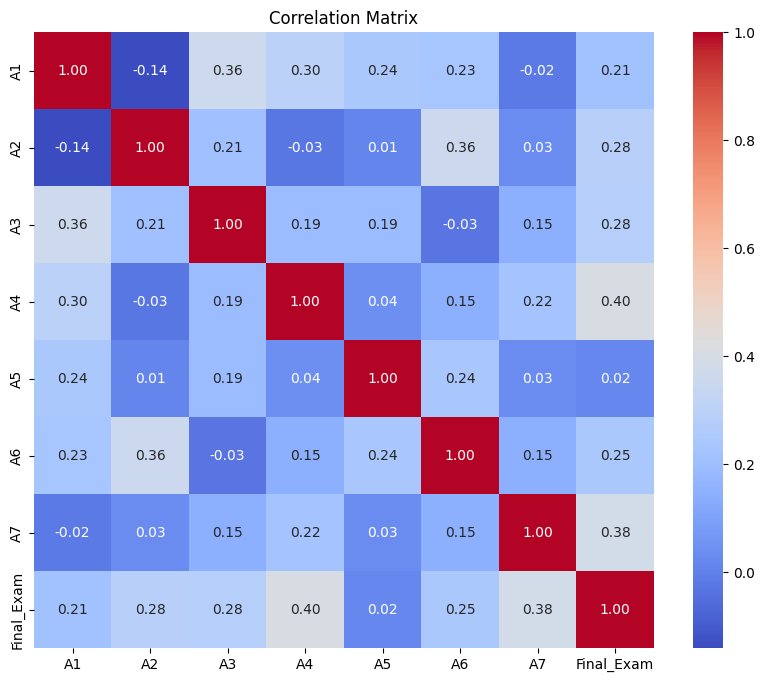


Correlation with Final_Exam:
A4    0.403
A7    0.381
A2    0.285
A3    0.278
A6    0.246
A1    0.213
A5    0.018
Name: Final_Exam, dtype: float64
Dynamic Selection: I choose **A4 and A7** because they mathematically have the highest correlation values with the Final Exam.

=== Missing Values Per Column ===
A1    29
A2    25
A3    24
A4     9
A5    25
A6    19
A7    10
dtype: int64

=== Initial Mess Diagnostic ===
- Total Rows Available: 86
- Complete rows with zero missing values: 13 rows
- **DANGER**: Dropping all missing rows drops your dataset size down from 86 entries to just 13!


In [47]:

# Lab Task 02: Cleaning Up the Mess - FINAL
# Name: Phumnawat
# Date: 29 May 2026


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# 1. Load & Explore Dataset

df = pd.read_csv('/content/sample_data/grades_crpt.csv')
print("✅ Dataset loaded! Shape:", df.shape)


print("\n=== Dataset Info ===")
print(df.info())

print("\n=== Summary Statistics (Before Cleaning) ===")
print(df.describe().round(2))

numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']



# 2. Correlation Analysis

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Get the top correlations excluding the Final Exam itself
corr_final = df[numeric_cols].corr()['Final_Exam'].drop('Final_Exam').sort_values(ascending=False)
print("\nCorrelation with Final_Exam:")
print(corr_final.round(3))

# Automatically extract the top two assignment names
top_1_assignment = corr_final.index[0]
top_2_assignment = corr_final.index[1]

print(f"Dynamic Selection: I choose **{top_1_assignment} and {top_2_assignment}** because they mathematically have the highest correlation values with the Final Exam.")



# 3. Missing Values & Structural Mess Check

print("\n=== Missing Values Per Column ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Initial Mess Diagnostic ===")
print(f"- Total Rows Available: {len(df)}")
print(f"- Complete rows with zero missing values: {len(df.dropna())} rows")
print(f"- **DANGER**: Dropping all missing rows drops your dataset size down from 86 entries to just {len(df.dropna())}!")

# Imputation Setup
df_mean = df.copy()
df_median = df.copy()
df_drop = df.dropna(subset=numeric_cols).copy()

for col in numeric_cols:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())
    df_median[col] = df_median[col].fillna(df_median[col].median())


=== Outliers Before Adjustment ===


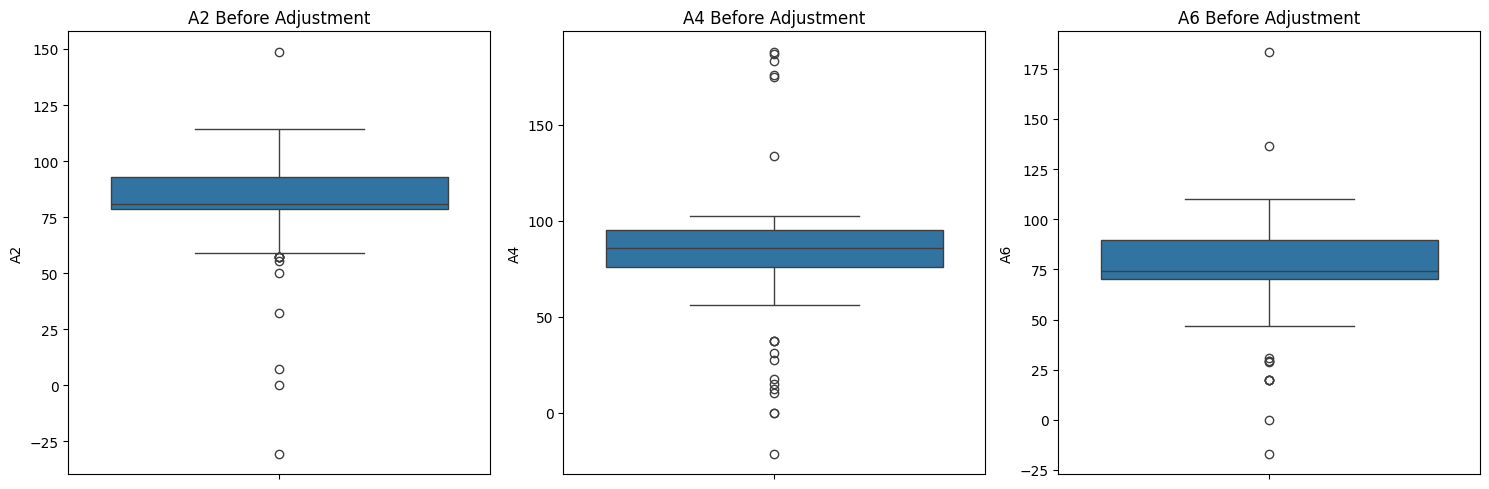

Suspicious high values in original data (A6 > 110):
       A6  Final_Exam
12  183.6        71.9
45  136.4        50.0

=== How I handled outliers ===
- If score > maximum allowed (including bonus) → set to max
- If score < 0 → set to 0
Outliers adjusted successfully.

=== Outliers After Adjustment ===


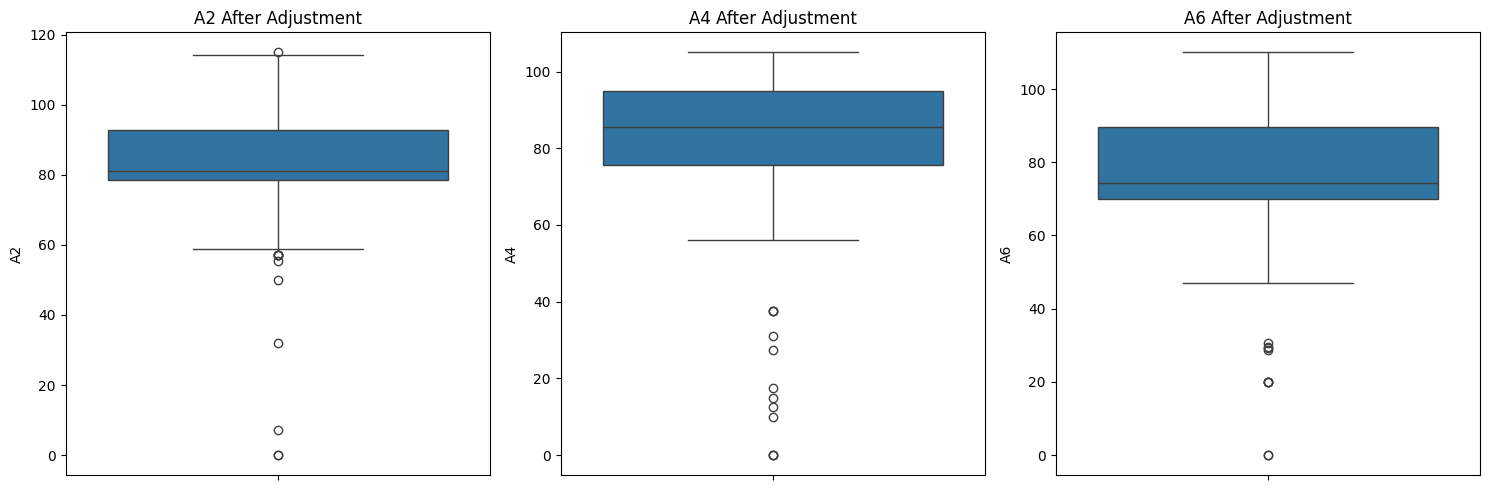

I decided to **modify** (clip) the outliers instead of removing them because removing would lose too much data.
Outliers and impossible negative grades cleaned up via boundary clipping.

=== Model Performance Comparison ===
Mean Imputation + Outlier Adjust: $R^2$ = 0.1274 | $\text{MSE}$ = 265.42
Median Imputation: $R^2$ = 0.0547 | $\text{MSE}$ = 287.54
Drop Missing Rows: $R^2$ = 0.4772 | $\text{MSE}$ = 575.28


0.477155790005626

In [49]:

# 4. Outliers

print("\n=== Outliers Before Adjustment ===")

# Keep df_before completely untouched as the true historical 'before' state
df_before = df_mean.copy()
# Create a separate dataframe to hold the clipped 'after' state
df_adjusted = df_mean.copy()

# Show boxplots for A2, A4, A6 (True Before state)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_before['A2'])
plt.title('A2 Before Adjustment')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_before['A4'])
plt.title('A4 Before Adjustment')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_before['A6'])
plt.title('A6 Before Adjustment')
plt.tight_layout()
plt.savefig('outliers_before.png')
plt.show()

print("Suspicious high values in original data (A6 > 110):")
print(df_before[df_before['A6'] > 110][['A6', 'Final_Exam']].head(10))

# === Apply outlier adjustment to df_adjusted only ===
print("\n=== How I handled outliers ===")
print("- If score > maximum allowed (including bonus) → set to max")
print("- If score < 0 → set to 0")

outlier_rules = {
    'A2': {'min': 0, 'max': 115},   # +15 bonus max
    'A4': {'min': 0, 'max': 105},   # +5 bonus max
    'A6': {'min': 0, 'max': 110}    # +10 bonus max
}

for col, lim in outlier_rules.items():
    df_adjusted[col] = df_adjusted[col].clip(lower=lim['min'], upper=lim['max'])

print("Outliers adjusted successfully.")

# Show After Adjustment (Using df_adjusted ensures graphs are visibly different!)
print("\n=== Outliers After Adjustment ===")
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_adjusted['A2'])
plt.title('A2 After Adjustment')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_adjusted['A4'])
plt.title('A4 After Adjustment')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_adjusted['A6'])
plt.title('A6 After Adjustment')
plt.tight_layout()
plt.savefig('outliers_after.png')
plt.show()

print("I decided to **modify** (clip) the outliers instead of removing them because removing would lose too much data.")

outlier_rules = {
    'A1': {'min': 0, 'max': 100},
    'A2': {'min': 0, 'max': 115},   # +15 bonus max
    'A3': {'min': 0, 'max': 100},
    'A4': {'min': 0, 'max': 105},   # +5 bonus max
    'A5': {'min': 0, 'max': 100},
    'A6': {'min': 0, 'max': 110},   # +10 bonus max
    'A7': {'min': 0, 'max': 100}
}

# Apply clipping across all assignments to fix negative grade bugs as well
for col, lim in outlier_rules.items():
    df_adjusted[col] = df_adjusted[col].clip(lower=lim['min'], upper=lim['max'])

print("Outliers and impossible negative grades cleaned up via boundary clipping.")


# 6. Evaluation Methods + Model Comparison

def evaluate_model(data, name):
    # Fix: Safely re-calculate the top features inside the function to avoid NameErrors
    numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
    corr_final = data[numeric_cols].corr()['Final_Exam'].drop('Final_Exam').sort_values(ascending=False)

    # Dynamically tracking the true highest correlation features safely
    top_1 = corr_final.index[0]
    top_2 = corr_final.index[1]

    X = data[[top_1, top_2]]
    y = data['Final_Exam']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"{name}: $R^2$ = {r2:.4f} | $\\text{{MSE}}$ = {mse:.2f}")
    return r2

print("\n=== Model Performance Comparison ===")
evaluate_model(df_adjusted, "Mean Imputation + Outlier Adjust")
evaluate_model(df_median, "Median Imputation")
evaluate_model(df_drop, "Drop Missing Rows")